# NLP-Based Health Trend and Anomaly Detection in Global News Streams

This notebook analyzes global news data from the GDELT project to explore health-related trends, detect unusual activity spikes, and examine underlying topic structures.
All preprocessing, topic modeling, and anomaly detection are performed in external scripts. This notebook focuses on analysis and interpretation of precomputed results.

Data source: GDELT Project

In [41]:
# Imports and Setup
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent

plt.style.use("default")

In [30]:
# Load Processed Data

# Main dataset with topic assignments
df = pd.read_csv(BASE_DIR / "data/processed/gdelt_with_topics.csv")

df["date_only"] = pd.to_datetime(df["date_only"])

daily_counts = df.groupby("date_only").size().sort_index()

# Keyword trends
keyword_trends = pd.read_csv(
    BASE_DIR / "data/features/keyword_trends.csv",
    index_col=0,
    parse_dates=True
)

# Topic over time
topic_over_time = pd.read_csv(
    BASE_DIR / "data/features/topic_over_time.csv",
    index_col=0,
    parse_dates=True
)

# Precomputed anomaly dataset
anomalies = pd.read_csv(
    BASE_DIR / "data/processed/gdelt_with_anomalies.csv",
    parse_dates=["date_only"]
)

# Ensure datetime consistency
df["date_only"] = pd.to_datetime(df["date_only"])

df.head()

,keyword,title,date,url,source_country,domain,date_only,year,month,week,dominant_topic
0,virus,mission : impossible 2,2026-01-02 00:00:00+00:00,https://www.tvguide.co.uk/schedule/e543e117-ff...,NaN,tvguide.co.uk,2026-01-02,2026,1,1,0
1,virus,januárové novinky v kinách : dočkáme sa uleten...,2026-01-02 00:00:00+00:00,https://www.aktuality.sk/clanok/rZGWyqv/januar...,NaN,aktuality.sk,2026-01-02,2026,1,1,4
2,virus,"10 years after end of 1 - child policy , chi...",2026-01-01 23:45:00+00:00,https://www.ksl.com:443/article/51425945/10-ye...,NaN,ksl.com,2026-01-01,2026,1,1,0
3,virus,utah measles cases rise to 156 amid ongoing na...,2026-01-01 23:45:00+00:00,https://www.ksl.com:443/article/51426212/utah-...,NaN,ksl.com,2026-01-01,2026,1,1,4
4,virus,tracking flu and respiratory virus activity ac...,2026-01-01 23:45:00+00:00,https://www.wvtm13.com/article/alabama-health-...,NaN,wvtm13.com,2026-01-01,2026,1,1,1


In [9]:
# Dataset Overview

print("Total articles:", len(df))
print("\nDate range:", df["date_only"].min(), "→", df["date_only"].max())

print("Keyword distribution:")
print(df["keyword"].value_counts())

print("\nTopic assignments:")
print(df["dominant_topic"].value_counts().sort_index())

Total articles: 681

Date range: 2025-12-13 00:00:00 → 2026-01-02 00:00:00
Keyword distribution:
keyword
antimicrobial resistance    244
outbreak                    222
virus                       215
Name: count, dtype: int64

Topic assignments:
dominant_topic
0    168
1    116
2    138
3    124
4    135
Name: count, dtype: int64


## Time Series Analysis (News Volume)

We analyze how the volume of health-related news articles evolves over time.

In [10]:
print(type(daily_counts))
print(daily_counts.head())

<class 'pandas.Series'>
0    2025-12-13
1    2025-12-14
2    2025-12-15
3    2025-12-16
4    2025-12-17
Name: date_only, dtype: str


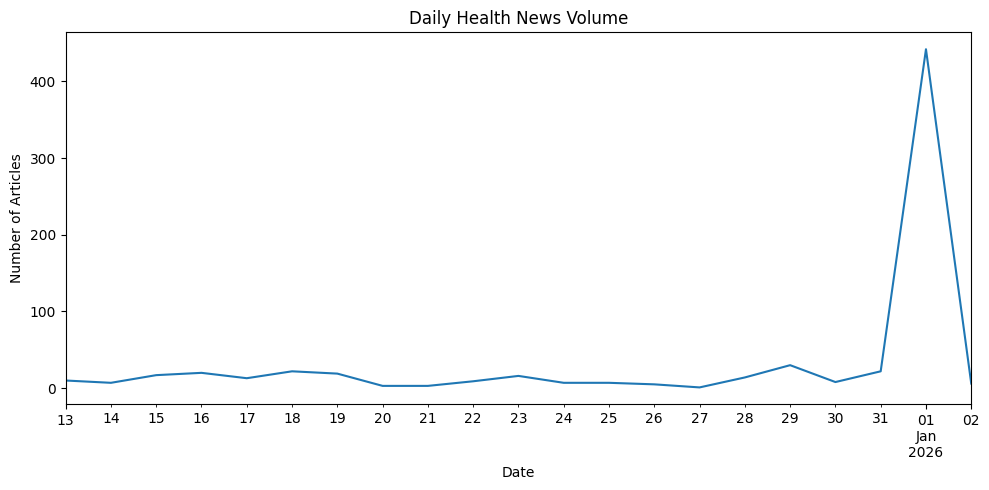

In [13]:
daily_counts.plot(figsize=(10,5))
plt.title("Daily Health News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/daily_trend.png")
plt.show()

## Keyword Trends Over Time

This visualization shows how different health-related topics vary across time.

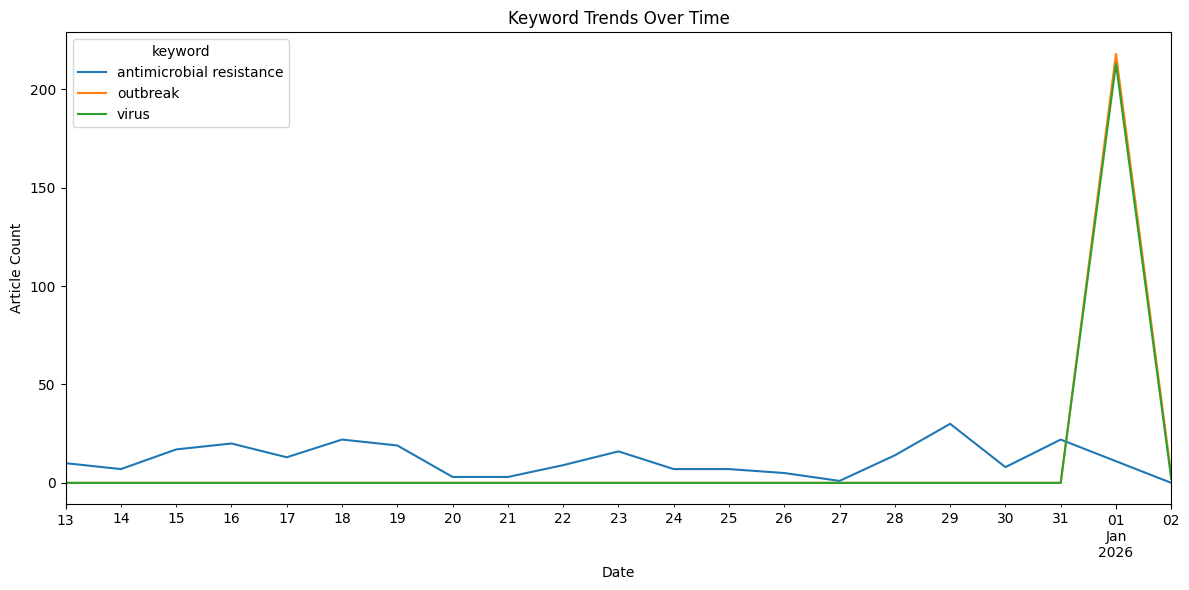

In [14]:
keyword_trends = df.groupby(["date_only", "keyword"]).size().unstack().fillna(0)

keyword_trends.plot(figsize=(12,6))

plt.title("Keyword Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/keyword_trends.png")
plt.show()

## Temporal Analysis Interpretation

The time-series analysis reveals a highly uneven distribution of health-related news coverage over time.

A significant peak is observed around January 1st, 2026, indicating a sudden surge in reporting activity. This spike is primarily driven by articles related to keywords such as "virus" and "outbreak", suggesting a clustering of news coverage around specific health events or reporting cycles.

In contrast, topics related to antimicrobial resistance show a more stable and consistently lower level of coverage across the observed time period, remaining below approximately 50 articles per day. This indicates that while antimicrobial resistance is an important topic, it does not exhibit the same level of short-term fluctuation as outbreak-related news.

Overall, the results suggest that certain health topics generate sharp, event-driven spikes in media attention, while others follow a more stable, long-term reporting pattern. This supports the idea that monitoring news volume can help identify emerging public health signals.

Some noise is present due to ambiguous keywords (e.g., "virus" used in non-health contexts), which represents a limitation of keyword-based data collection.

## Anomaly Detection

To identify unusual spikes in health-related news activity, we apply a statistical z-score method to detect unusual spikes in news volume over time.

This allows us to detect days where the volume of articles significantly deviates from the average.

In [31]:
mean = daily_counts.mean()
std = daily_counts.std()

z_scores = (daily_counts - mean) / std
anomalies = daily_counts[z_scores > 2.0]

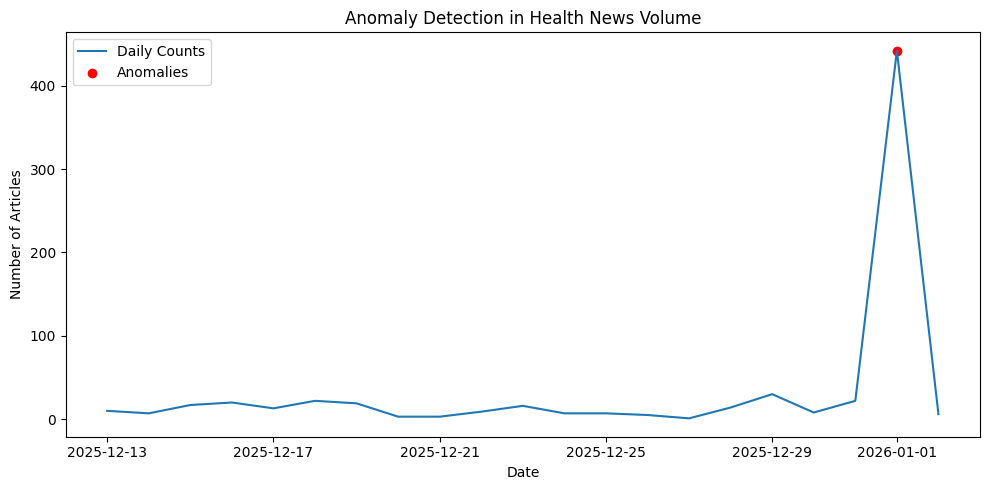

In [33]:
plt.figure(figsize=(10,5))

plt.plot(daily_counts.index, daily_counts.values, label="Daily Counts")

plt.scatter(
    anomalies.index,
    anomalies.values,
    color="red",
    label="Anomalies"
)

plt.title("Anomaly Detection in Health News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/anomalies.png")
plt.show()

## Anomaly Interpretation

The anomaly detection method identifies a clear outlier on January 1st, 2026, with 442 articles, which is significantly higher than the baseline activity observed on other days.

This confirms the previously observed spike in the time-series analysis and demonstrates that statistical anomaly detection can successfully capture sudden increases in news volume.

The detected anomaly is primarily driven by outbreak-related keywords, suggesting a concentrated media response to a specific health-related event or reporting cycle. This type of signal could be relevant for early warning systems in public health monitoring.

Such spikes may correspond to real-world events or reporting cycles, highlighting the usefulness of news data for monitoring emerging public health signals.

## Topic Distribution Overview

We examine the overall distribution of topics identified by the LDA model.

But first, in order to interpret the LDA topics, we inspect the top words associated with each topic.
These word distributions help us assign semantic meaning to each topic later in the analysis.

In [42]:
# Topic Inspection (Top Words per Topic)

# Rebuild LDA interpretation
lda = joblib.load(BASE_DIR / "models/lda_model.pkl")
vectorizer = joblib.load(BASE_DIR / "models/tfidf_vectorizer.pkl")

words = vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"\nTopic {idx}: {', '.join(top_words)}")



Topic 0: antibiotic, resistance, new, antimicrobial, en, antibiotics, com, year, years, india

Topic 1: en, iran, la, el, protests, flu, clashes, living, cost, fresh

Topic 2: 40, 2025, tote, amid, war, cases, drama, silvesterparty, montana, crans

Topic 3: في, 2026, حريق, من, إيران, se, عاجل, indore, water, care

Topic 4: health, la, 10, 博客, 2025, din, bacteria, на, ai, 2026


## Topic Interpretation Guide

Based on the top-word inspection of the LDA model, the following interpretations were assigned to each topic:

- **Topic 0:** Antimicrobial resistance and antibiotic-related health research
- **Topic 1:** Geopolitical events with partial health coverage (e.g., flu, protests)
- **Topic 2:** General breaking news and mixed global events
- **Topic 3:** Arabic-language breaking news and regional crisis reporting
- **Topic 4:** Multilingual health-related content with noise (mixed quality signals)

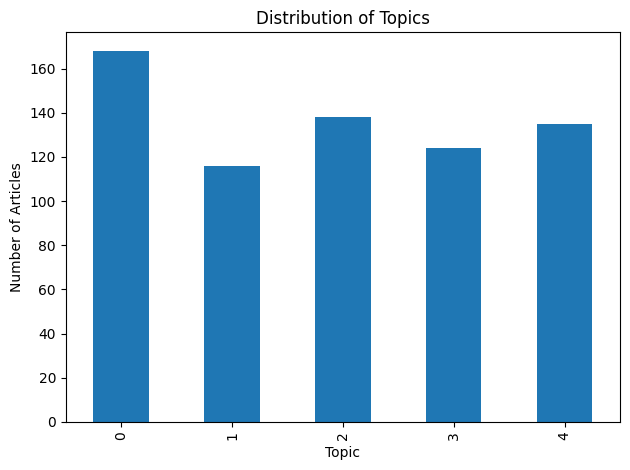

In [45]:
topic_counts = df["dominant_topic"].value_counts().sort_index()

topic_counts.plot(kind="bar")

plt.title("Distribution of Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/topic_distribution.png")
plt.show()

## Topic Distribution Interpretation

The topic modeling results reveal several distinct thematic clusters within the dataset.

One topic is strongly associated with antimicrobial resistance and antibiotic-related terminology, making it highly relevant to public health surveillance and aligned with the focus of this project.

Other topics reflect a mixture of global news content, including geopolitical events, general reporting, and multilingual news sources. This highlights the diversity of the underlying data, which is drawn from global news streams rather than a curated health corpus.

Some topics contain mixed or noisy signals, combining health-related terms with unrelated political or cultural events. This is expected in large-scale open news datasets such as GDELT, where keyword-based retrieval introduces semantic ambiguity.

Overall, the results demonstrate that while health-related discourse can be clearly identified, it exists within a broader and heterogeneous global news environment. This supports the need for more advanced filtering or semantic modeling in future work.

## Topic Composition During Anomalies

To better understand the nature of detected anomalies, we compare topic distributions between anomaly days and normal days.

In [38]:
#Normalize dates for matching

df["date_only"] = pd.to_datetime(df["date_only"]).dt.normalize()
anomalies.index = pd.to_datetime(anomalies.index).normalize()
anomaly_days = anomalies.index.normalize()

#Split datasets

anomaly_df = df[df["date_only"].isin(anomaly_days)]
normal_df = df[~df["date_only"].isin(anomaly_days)]

print("Anomaly rows:", len(anomaly_df))
print("Normal rows:", len(normal_df))

Anomaly rows: 442
Normal rows: 239


In [39]:
anomaly_topic_counts = anomaly_df["dominant_topic"].value_counts().sort_index()
normal_topic_counts = normal_df["dominant_topic"].value_counts().sort_index()

comparison = pd.DataFrame({
"anomaly": anomaly_topic_counts,
"normal": normal_topic_counts
}).fillna(0)

comparison

,anomaly,normal
dominant_topic,,
0,96,72
1,68,48
2,106,32
3,91,33
4,81,54


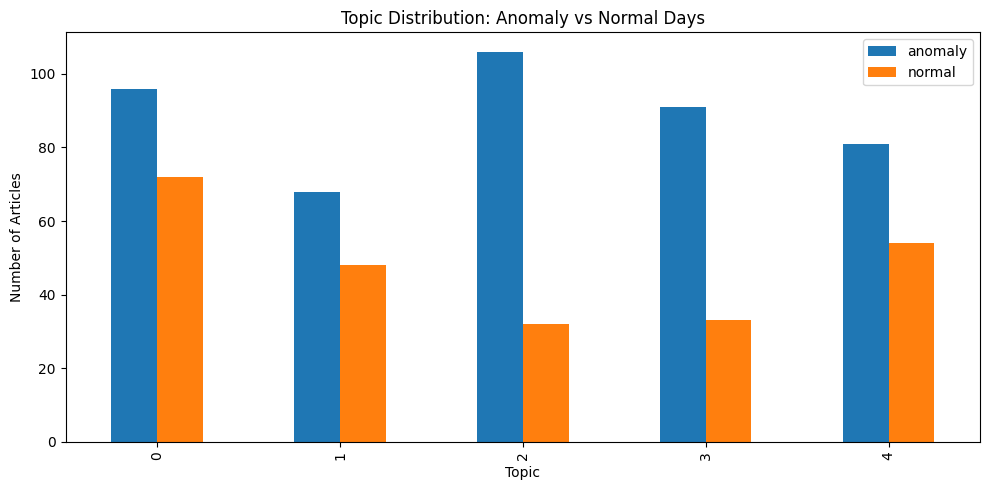

In [40]:
comparison.plot(kind="bar", figsize=(10,5))

plt.title("Topic Distribution: Anomaly vs Normal Days")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/anomaly_vs_normal_topics.png", dpi=300, bbox_inches="tight")
plt.show()

## Anomaly–Topic Relationship Interpretation

The anomaly period (January 1st, 2026) contains 442 articles and shows a distribution across all identified topics rather than a single dominant category.

Topic 2 represents the largest share of the anomaly period, followed closely by Topics 0 and 3. This indicates that the detected spike is not driven by a single thematic event, but rather reflects a broad increase in global news activity across multiple domains.

Notably, health-related and outbreak-associated topics (e.g., antimicrobial resistance and infectious disease reporting) are present but not exclusively dominant during the anomaly period.

This suggests that while statistical anomaly detection successfully identifies periods of increased activity, further semantic refinement is required to distinguish between general news surges and true public health-specific events.

Overall, this highlights both the strength and limitation of using raw news volume as a proxy for public health signal detection.

## Topic Evolution Over Time

We analyze how topic distributions change over time to identify temporal dynamics and potential event-driven shifts.

In [22]:
#Aggregate topic counts over time

topic_over_time = df.groupby(["date_only", "dominant_topic"]).size().unstack().fillna(0)

topic_over_time.head()

dominant_topic,0,1,2,3,4
date_only,,,,,
2025-12-13,2.0,0.0,4.0,3.0,1.0
2025-12-14,3.0,2.0,1.0,0.0,1.0
2025-12-15,3.0,3.0,3.0,3.0,5.0
2025-12-16,2.0,13.0,0.0,2.0,3.0
2025-12-17,3.0,2.0,3.0,2.0,3.0


In [23]:
#Smoothed trend

topic_over_time_smoothed = topic_over_time.rolling(window=3).mean()

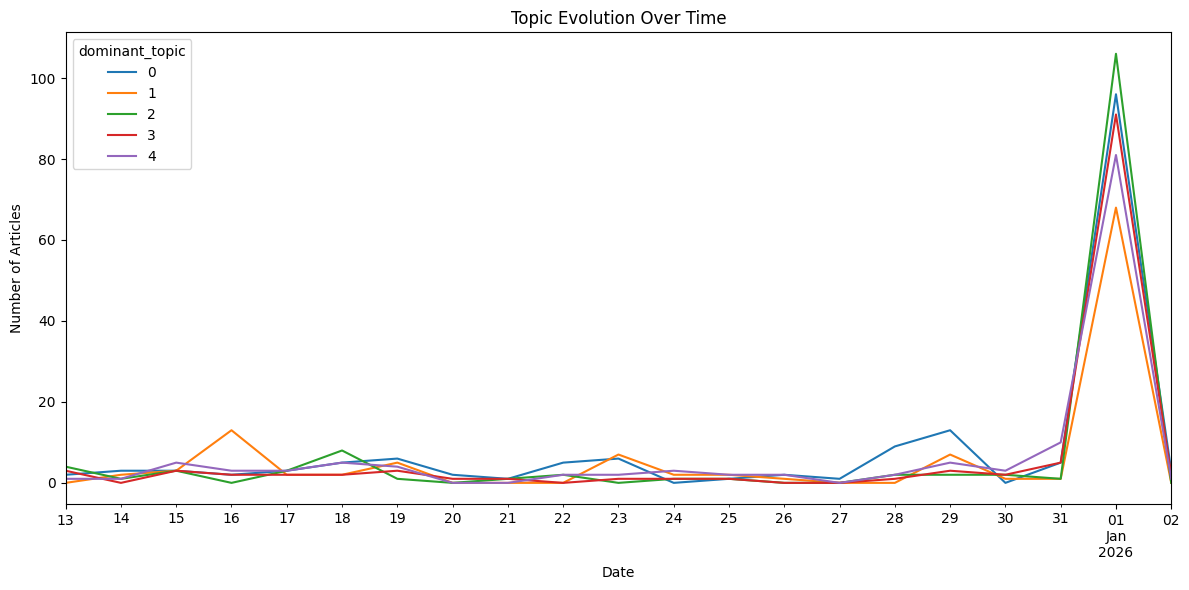

In [24]:
topic_over_time.plot(figsize=(12,6))

plt.title("Topic Evolution Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/topic_evolution.png")
plt.show()

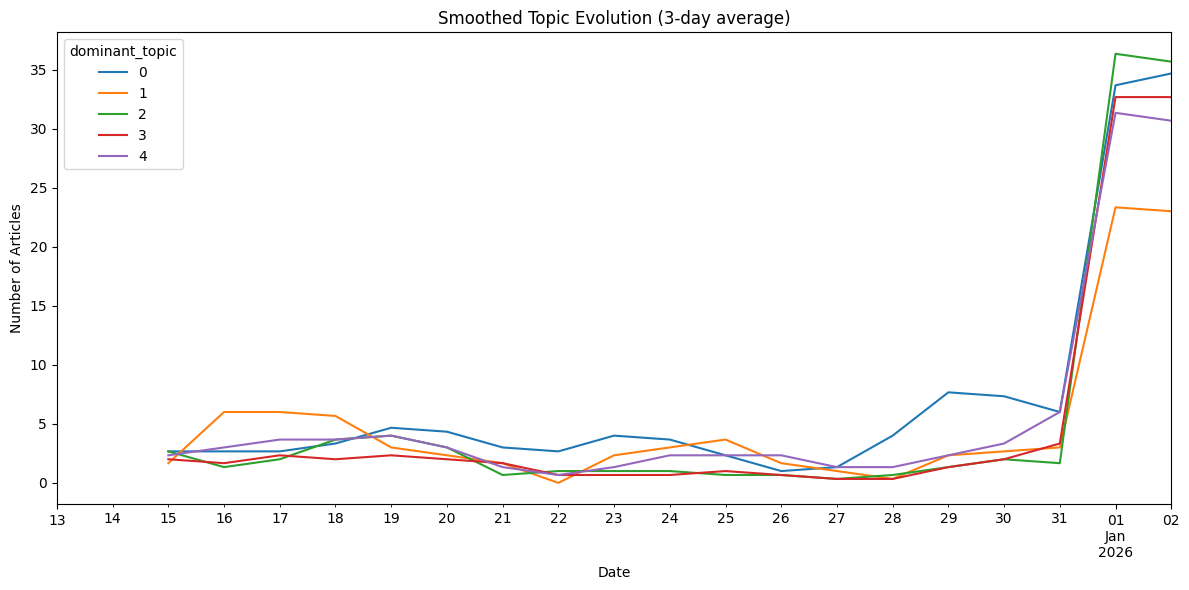

In [25]:
topic_over_time_smoothed.plot(figsize=(12,6))

plt.title("Smoothed Topic Evolution (3-day average)")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/topic_evolution_smoothed.png")
plt.show()

## Topic Evolution Over Time Interpretation

The topic evolution analysis shows how different thematic clusters develop across the observed time period (13 December 2025 to 2 January 2026).

Overall, all topics exhibit low and relatively stable daily counts for most of the time window, with values typically ranging between 1 and 10 articles per day. This indicates a consistent baseline level of news coverage across all identified themes.

However, a sharp and synchronized increase is observed across all topics on 1 January 2026, where all topic categories show a significant surge in activity. This suggests that the detected peak is not topic-specific, but rather reflects a general increase in news volume affecting multiple domains simultaneously.

Among the topics, Topic 2 shows the highest peak intensity, indicating that it is more sensitive to short-term spikes in news coverage. In contrast, Topic 1 remains the least active across time, suggesting it represents more niche or less frequently reported content.

The results indicate that topic dynamics in this dataset are primarily driven by external event bursts rather than gradual topic shifts over time.

In [26]:
# Key Observations

print("Top 5 most active days:")
print(daily_counts.sort_values(ascending=False).head())

peak_day = daily_counts.idxmax()

print("\nPeak day:", peak_day)

print("\nTopic distribution on peak day:")
peak_data = df[df["date_only"] == peak_day]
print(peak_data["dominant_topic"].value_counts().sort_index())

Top 5 most active days:
date_only
2026-01-01    442
2025-12-29     30
2025-12-18     22
2025-12-31     22
2025-12-16     20
dtype: int64

Peak day: 2026-01-01 00:00:00

Topic distribution on peak day:
dominant_topic
0     96
1     68
2    106
3     91
4     81
Name: count, dtype: int64


## Overall Results Summary

This section consolidates the main findings from temporal, anomaly, and topic-based analyses.

The analysis of global health-related news streams reveals a highly dynamic system characterized by a stable baseline of reporting interrupted by sharp event-driven spikes.

The dataset covers a short time window (13 December 2025 – 2 January 2026) and contains 681 articles. A dominant anomaly is detected on 1 January 2026, accounting for approximately 65% of all collected data, indicating a significant surge in global news activity.

Topic modeling reveals a heterogeneous structure of five latent topics. While some topics remain relatively stable over time, others exhibit strong sensitivity to short-term events, particularly during the detected anomaly period.

Temporal analysis further confirms that most topics maintain low and steady activity levels, with sudden synchronized increases across all topics during peak events. This suggests that observed spikes are not driven by single-topic outbreaks but rather by broad, system-wide increases in news reporting.

However, the presence of noise introduced by keyword-based data collection (e.g., non-health-related content within generic terms like "virus") highlights the limitations of relying solely on lexical filtering for public health surveillance.

Overall, the system demonstrates the potential of combining topic modeling, time-series analysis, and anomaly detection for monitoring health-related information flows, while also emphasizing the need for more refined semantic filtering methods in future work.

These findings demonstrate that combining temporal and semantic analysis enables more robust interpretation of large-scale news streams, but still requires improved disambiguation of health-specific signals.